Classifiers
#### or: How I Learned to Stop Worrying and Love Machine Learning

Lia Du

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# Exploratory Data Analysis
### Reading data

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
train.info()
print(train.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
       PassengerId HomePlanet CryoSleep    Cabin  Destination          Age  \
count         8693       8492      8476     8494         8511  8

In [ ]:
print("\nmissing values in train:\n", train.isnull().sum())


missing values in train:
 PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


### Visualizing (age distribution, CryoSleep counts, correlation heatmap)

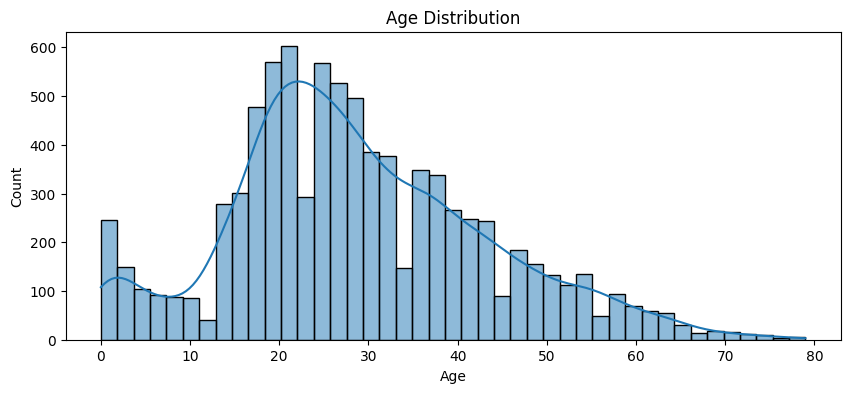

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(train['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

The most common age group are young adults, however, with a sudden drop in passengers aged ~24. Overall, the age group decreases slightly then sharply increases, and then follows a steady downward trend.

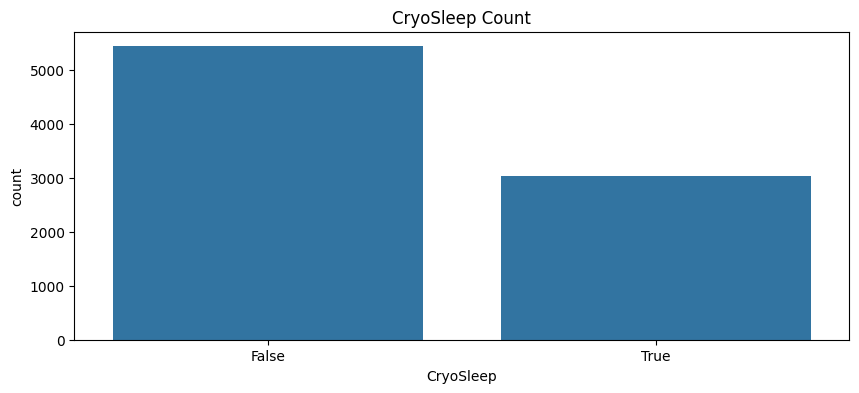

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x='CryoSleep', data=train)
plt.title("CryoSleep Count")
plt.show()

More passengers are *not* put to "cryosleep" (suspended animation), around 2x the amount of passengers that are put to "cryosleep."

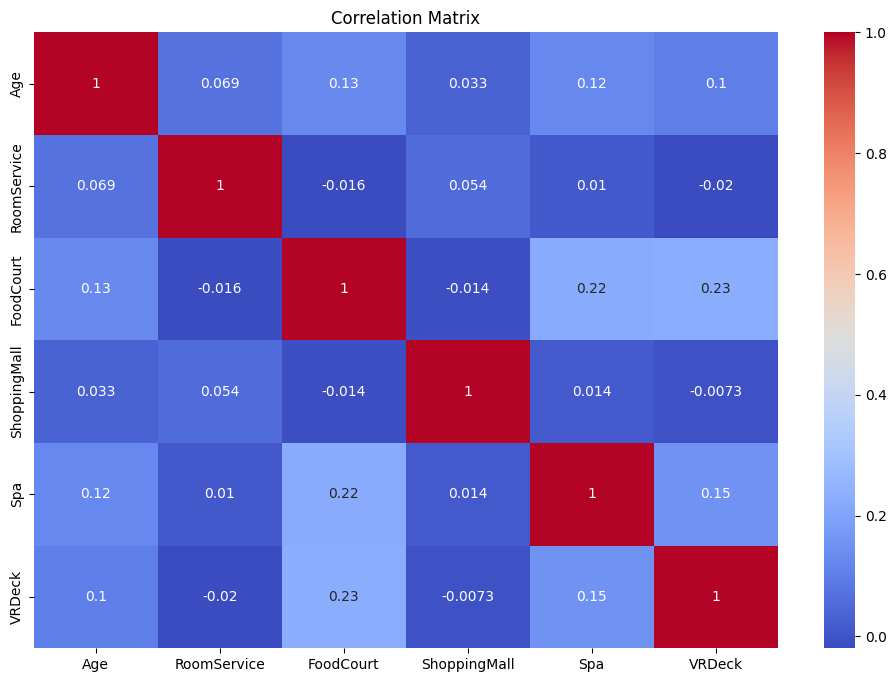

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

 Overall, the correlations are quite weak, with values ranging mostly between –0.02 and 0.23. The strongest positive correlations appear between FoodCourt and VRDeck (0.23) and between FoodCourt and Spa (0.22), which suggests that passengers who spend more in the FoodCourt tend to spend slightly more on VRDeck and Spa as well. Age shows only weak positive relationships with other variables, indicating that spending habits are not strongly influenced by age. RoomService and ShoppingMall also show minimal correlation with other categories. Since no strong correlations exist, it suggests that each variable represents largely independent spending behavior and multicollinearity is likely not to be a concern in predictive modeling.

# Feature engineering
### Splitting cabin column

In [ ]:
# split 'Cabin' column into separate components and create a new feature for total expenses
for df in [train, test]:
    df['Name'] = df['Name'].fillna('Unknown')
    df['Cabin'] = df['Cabin'].fillna('Unknown/0/0')
    df[['Deck','CabinNum','Side']] = df['Cabin'].str.split('/', expand=True)
    df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

for df in [train, test]:
    df['TotalExpenses'] = df[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)

# Modeling
### Addressing NA values

In [ ]:
# fill categorical and numeric missing values
cat_cols = ['HomePlanet','CryoSleep','Destination','VIP','Deck','Side']
num_cols = ['Age','RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','CabinNum','TotalExpenses']

for df in [train, test]:
    for c in cat_cols:
        df[c] = df[c].fillna(df[c].mode()[0])
    for n in num_cols:
        df[n] = df[n].fillna(df[n].median())

print("\nmissing vals:\n", train.isnull().sum())


missing vals:
 PassengerId      0
HomePlanet       0
CryoSleep        0
Cabin            0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Name             0
Transported      0
Deck             0
CabinNum         0
Side             0
TotalExpenses    0
dtype: int64


/var/folders/dp/ckl63ln114957k4x2fttsb2w0000gn/T/ipykernel_38237/2556936742.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].fillna(df[c].mode()[0])
/var/folders/dp/ckl63ln114957k4x2fttsb2w0000gn/T/ipykernel_38237/2556936742.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].fillna(df[c].mode()[0])


### Encode categorical variables and scale numeric features

In [ ]:
le = LabelEncoder()
for c in cat_cols:
    train[c] = le.fit_transform(train[c].astype(str))
    test[c] = le.transform(test[c].astype(str))

scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

### Split features and target

In [ ]:
X = train.drop(['PassengerId','Name','Cabin','Transported'], axis=1)
y = train['Transported'].astype(int)
X_test = test.drop(['PassengerId','Name','Cabin'], axis=1)

### Classifiers and ensemble

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
cat_model = CatBoostClassifier(verbose=0, random_state=42)

voting_model = VotingClassifier(
    estimators=[('rf', rf_model), ('cat', cat_model)],
    voting='soft')

voting_model.fit(X, y)

,estimators,"[('rf', ...), ('cat', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


# Predicting on Test Data

In [ ]:
y_pred_train = voting_model.predict(X)
train_acc = accuracy_score(y, y_pred_train)
print("VotingClassifier training accuracy:", train_acc)

VotingClassifier training accuracy: 0.9697457724606005


In [ ]:
predictions = voting_model.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': predictions.astype(bool)})

submission.to_csv('submission.csv', index=False)
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


![Screenshot 2025-11-10 at 9.05.23 PM.png](<attachment:Screenshot 2025-11-10 at 9.05.23 PM.png>)